## 1. Importing Libraries and setting up CUDA



In [1]:
import os
import shutil
from IPython.display import Image, clear_output

import numpy as np
import torch
import json

import matplotlib.pyplot as plt

In [2]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cuda'

## 2. Preparing Data for Training


### 2.1 Verifications of Dataset Structure


In [3]:
for dirpath, dirnames, filenames in os.walk("/kaggle/input/"):
    for dirname in dirnames:
        full_path = os.path.join(dirpath, dirname)
        print(full_path)

/kaggle/input/datasets
/kaggle/input/datasets/awsaf49
/kaggle/input/datasets/awsaf49/coco-2017-dataset
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017


In [4]:
# Extract the path for both the images and the annotations for it
base_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
images_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
annotations_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations"
test_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017"

In [5]:
print(f"Annotations: {os.listdir(annotations_path)}")
print(f"No. of training images: {len(os.listdir(images_path))}")
print(f"No. of test path: {len(os.listdir(test_path))}")

Annotations: ['person_keypoints_train2017.json', 'instances_val2017.json', 'instances_train2017.json', 'person_keypoints_val2017.json', 'captions_train2017.json', 'captions_val2017.json']
No. of training images: 118287
No. of test path: 40670


In [6]:
for dirpath, dirnames, filenames in os.walk(annotations_path):
    for filename in filenames: 
        full_path = os.path.join(dirpath, filename)
        print(full_path)

/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/person_keypoints_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/person_keypoints_val2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json


### 2.2 Modifying the dataset as per the YOLO requirements
Here, we parse the COCO data/ build the helper functions as per required

1. **Letterboxing**
   This reshapes the images to the square shape, while padding for the side where needed. This improves GPU optimization, Batch processing and so on.

2. **Aggregation**
    This aggregrates all bounding box annotations by image ID

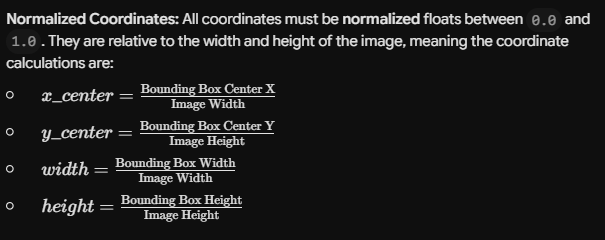

In [7]:
# LetterBoxing - converts bounding box to cooridinates on a unit square

def scale_box(box, width, height):
    scale = 1.0 / max(width, height)
    x, y , w, h = [v * scale for v in box]
    x += (height - width) * scale / 2 if height > width else 0
    y += (width - height) * scale / 2 if width > height else 0
    return [x,y,w,h]

### 2.3 Sneak-peak at the json file for annotations and Aggregation


In [8]:
train_instances_json = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json"

In [9]:
with open(train_instances_json, "r") as file:
    data = json.load(file)

type(data)

dict

In [10]:
data.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [11]:
data['images'][0]

{'license': 3,
 'file_name': '000000391895.jpg',
 'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
 'height': 360,
 'width': 640,
 'date_captured': '2013-11-14 11:18:45',
 'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg',
 'id': 391895}

In [12]:
data['annotations'][0]

{'segmentation': [[239.97,
   260.24,
   222.04,
   270.49,
   199.84,
   253.41,
   213.5,
   227.79,
   259.62,
   200.46,
   274.13,
   202.17,
   277.55,
   210.71,
   249.37,
   253.41,
   237.41,
   264.51,
   242.54,
   261.95,
   228.87,
   271.34]],
 'area': 2765.1486500000005,
 'iscrowd': 0,
 'image_id': 558840,
 'bbox': [199.84, 200.46, 77.71, 70.88],
 'category_id': 58,
 'id': 156}

In [13]:
len(data['annotations'])

860001

In [14]:
# Aggregating Metadata
images = {image['id']: image for image in data['images']}

metadata = {}
for annotation in data['annotations']:
    id = annotation['image_id']
    if id not in metadata:
        metadata[id] = {
            "boxes" : [], 
            "labels" : []
        }

    image = images[id]
    box = scale_box(annotation['bbox'], image['width'], image['height'])
    metadata[id]['boxes'].append(box)
    metadata[id]['labels'].append(annotation['category_id'])
    metadata[id]["path"] = images_path + "/" + image['file_name']

metadata = list(metadata.values())    

In [15]:
metadata[0]

{'boxes': [[0.31225, 0.4796250000000001, 0.121421875, 0.11075],
  [0.508234375, 0.3295, 0.05260937500000001, 0.165609375],
  [0.263828125, 0.3085625, 0.049093750000000005, 0.13864062500000002],
  [0.003, 0.30376562500000004, 0.05460937500000001, 0.273984375],
  [0.54153125, 0.168078125, 0.456265625, 0.537046875],
  [0.3735625, 0.23315625, 0.0310625, 0.11989062500000001],
  [0.640515625, 0.503, 0.11225000000000002, 0.07831250000000001],
  [0.0015, 0.168, 0.1454375, 0.25039062500000003],
  [0.431859375, 0.187984375, 0.049609375000000004, 0.096203125],
  [0.005203125, 0.57884375, 0.56146875, 0.244359375],
  [0.6461562500000001,
   0.48187500000000005,
   0.11373437500000001,
   0.08809375000000001]],
 'labels': [58, 44, 44, 47, 1, 44, 50, 1, 44, 67, 50],
 'path': '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000558840.jpg'}

In [16]:
!pip install pycocotools

In [17]:
len(metadata)

117266

### 2.4 Listing classes in COCO Dataset

In [18]:
from pycocotools.coco import COCO

coco = COCO(train_instances_json)

loading annotations into memory...
Done (t=13.26s)
creating index...
index created!


In [19]:
categories = coco.loadCats(coco.getCatIds())
class_names = [category['name'] for category in categories]
print("Classes in COCO dataset", class_names)

Classes in COCO dataset ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [20]:
categories_by_name = {category['id']: category['name'] for category in categories}
categories_by_name

{1: 'person',
 2: 'bicycle',
 3: 'car',
 4: 'motorcycle',
 5: 'airplane',
 6: 'bus',
 7: 'train',
 8: 'truck',
 9: 'boat',
 10: 'traffic light',
 11: 'fire hydrant',
 13: 'stop sign',
 14: 'parking meter',
 15: 'bench',
 16: 'bird',
 17: 'cat',
 18: 'dog',
 19: 'horse',
 20: 'sheep',
 21: 'cow',
 22: 'elephant',
 23: 'bear',
 24: 'zebra',
 25: 'giraffe',
 27: 'backpack',
 28: 'umbrella',
 31: 'handbag',
 32: 'tie',
 33: 'suitcase',
 34: 'frisbee',
 35: 'skis',
 36: 'snowboard',
 37: 'sports ball',
 38: 'kite',
 39: 'baseball bat',
 40: 'baseball glove',
 41: 'skateboard',
 42: 'surfboard',
 43: 'tennis racket',
 44: 'bottle',
 46: 'wine glass',
 47: 'cup',
 48: 'fork',
 49: 'knife',
 50: 'spoon',
 51: 'bowl',
 52: 'banana',
 53: 'apple',
 54: 'sandwich',
 55: 'orange',
 56: 'broccoli',
 57: 'carrot',
 58: 'hot dog',
 59: 'pizza',
 60: 'donut',
 61: 'cake',
 62: 'chair',
 63: 'couch',
 64: 'potted plant',
 65: 'bed',
 67: 'dining table',
 70: 'toilet',
 72: 'tv',
 73: 'laptop',
 74: 'mo

In [21]:
metadata[435]

{'boxes': [[0.12471874999999999, 0.275, 0.57640625, 0.333703125],
  [0.0, 0.152078125, 0.7938125, 0.687640625],
  [0.0, 0.125140625, 1.0, 0.7498593750000001]],
 'labels': [17, 15, 2],
 'path': '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000171809.jpg'}

In [22]:
# Example for labels

labels = [categories_by_name[id] for id in metadata[435]['labels']]
labels

['cat', 'bench', 'bicycle']

In [23]:
list(images.keys())[435]

557556

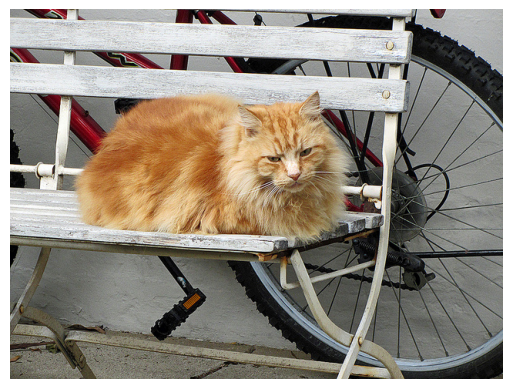

In [24]:
from PIL import Image

img = Image.open("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000171809.jpg")
plt.imshow(img)
plt.axis('off')
plt.show()

In [25]:
images[171809]['coco_url']

'http://images.cocodataset.org/train2017/000000171809.jpg'